#### Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from pathlib import Path
import pickle
import warnings
import os
from typing import Dict, List, Tuple, Optional

warnings.filterwarnings('ignore')

from kmrf import KMRF
from KMRF_training_config import *
from MODEL_INFO import MODEL_INFO
from ANALYTICAL_INPUTS import ANALYTICAL_INPUTS
from PORTFOLIO_OPTIMIZER import PORTFOLIO_OPTIMIZER
from BACKTEST_ANALYTICAL import BACKTEST

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# import itables
# itables.init_notebook_mode()
# import pygwalker as pyg

#### Global Vars and Helper Functions

In [3]:
KM_MODEL_BASE_PATH = Path('saved_models/KAMA_MSR/us_equity')
KMRF_PREDICTIONS_BASE_PATH = Path('data/multi_horizon_predictions')

# Using saved KAMA+MSR models
def get_KM_model_dates(KM_MODEL_BASE_PATH = Path('saved_models/KAMA_MSR/us_equity')) -> pd.Series:
    return pd.Series([f.stem for f in list(KM_MODEL_BASE_PATH.glob('*'))]).sort_values().iloc[1:].reset_index(drop=True)

def get_KM_model_paths(MODEL_DATE: str, KM_MODEL_BASE_PATH = Path('saved_models/KAMA_MSR/us_equity')) ->  pd.Series:
    return pd.Series(list((KM_MODEL_BASE_PATH / MODEL_DATE).glob('*'))).sort_values().reset_index(drop=True)

# Using saved KMRF predictions
def get_asset_names(KMRF_PREDICTIONS_BASE_PATH = Path('data/multi_horizon_predictions')) -> pd.Series:
    kmrf_preds_paths = list(KMRF_PREDICTIONS_BASE_PATH.glob('*'))
    return pd.Series([f.stem.split('multi')[0][:-1].replace('_', ' ') for f in kmrf_preds_paths]).sort_values().reset_index(drop=True)

def get_KMRF_prediction_paths(KMRF_PREDICTIONS_BASE_PATH = Path('data/multi_horizon_predictions')) -> pd.Series:
    return pd.Series(list(KMRF_PREDICTIONS_BASE_PATH.glob('*'))).sort_values().reset_index(drop=True)

In [4]:
from pandas.tseries.holiday import USFederalHolidayCalendar
from pandas.tseries.offsets import CustomBusinessDay

TRADING_DAYS = CustomBusinessDay(calendar=USFederalHolidayCalendar())

RF_RATES_TS = pd.read_csv('data/risk_free_rates.csv', parse_dates=['Date'], index_col='Date')[['RF_3M']].sort_index()

# ----------------------------------------------------

In [5]:
KM_MODEL_DATES = get_KM_model_dates()

In [6]:
START_DATE = KM_MODEL_DATES.iloc[0]
END_DATE = '20251031'

N_FREQ = 5 # Edit this
ALLOW_SHORT = False # Edit this

GROSS_EXPOSURE_LIMIT = 2.0 if ALLOW_SHORT else 1.0
MIN_WEIGHT = -0.5 if ALLOW_SHORT else 0.0
MAX_WEIGHT = 1.0 # Edit this

OBJECTIVE = 'max_sharpe'  # max_sharpe, min_variance, risk_parity, or mean_variance
RISK_AVERSION = 1.0  # Only used if OBJECTIVE is 'mean_variance'

MAIN_FOLDER = 'saved_backtests_NEW'

EVAL_SDTE = None
EVAL_EDTE = None

In [7]:
assets_type = 'sectors-and-metals' # Edit this

subfolder = f'{OBJECTIVE}_no_constraints'
if MAX_WEIGHT < 1.0:
    subfolder = f'{OBJECTIVE}_max_weight={MAX_WEIGHT}'

investment_type = 'long-short' if ALLOW_SHORT else 'long-only'
investment_type_w_gross = f'long-short_gross={GROSS_EXPOSURE_LIMIT}' if ALLOW_SHORT else f'long-only'

filename = f'{assets_type}_{investment_type_w_gross}_'
if OBJECTIVE == 'mean_variance':
    filename += f'risk-aversion={RISK_AVERSION}_'
filename += f'{N_FREQ}d-rebal_{START_DATE}-{END_DATE}.pkl'

filename

'sectors-and-metals_long-only_5d-rebal_20181231-20251031.pkl'

In [8]:
with open(os.path.join(MAIN_FOLDER, subfolder, f'{assets_type}_universe', investment_type, filename), 'rb') as f:
    bt = pickle.load(f)

In [9]:
bt._compute_benchmarks()

In [10]:
rets = bt.returns.rename('Regime-Aware MV').to_frame()\
    .join(bt.benchmark_returns['MV Historical (Rebal)'].rename('Benchmark (Standard MV)'))

rets = rets.loc[EVAL_SDTE:EVAL_EDTE]
rets

,Regime-Aware MV,Benchmark (Standard MV)
date,,
2019-01-02,-0.009775,-0.004772
2019-01-03,0.006382,-0.000925
2019-01-04,0.003056,0.004561
2019-01-07,0.005833,0.003589
2019-01-08,0.007672,0.003823
...,...,...
2025-10-27,-0.000669,-0.009991
2025-10-28,0.000491,-0.002884
2025-10-29,0.000199,-0.003477


In [11]:
rets_filename = f'{filename[:-4]}_returns.csv'
rets_filepath = os.path.join(MAIN_FOLDER, subfolder, f'{assets_type}_universe', investment_type, rets_filename)

rets.to_csv(rets_filepath)

In [12]:
import quantstats as qs

report_filename = f'{filename[:-4]}_report.html'
report_filepath = os.path.join(MAIN_FOLDER, subfolder, f'{assets_type}_universe', investment_type, report_filename)
qs.reports.html(rets['Regime-Aware MV'], rets['Benchmark (Standard MV)'], output=report_filepath)

# ----------------------------------------------------

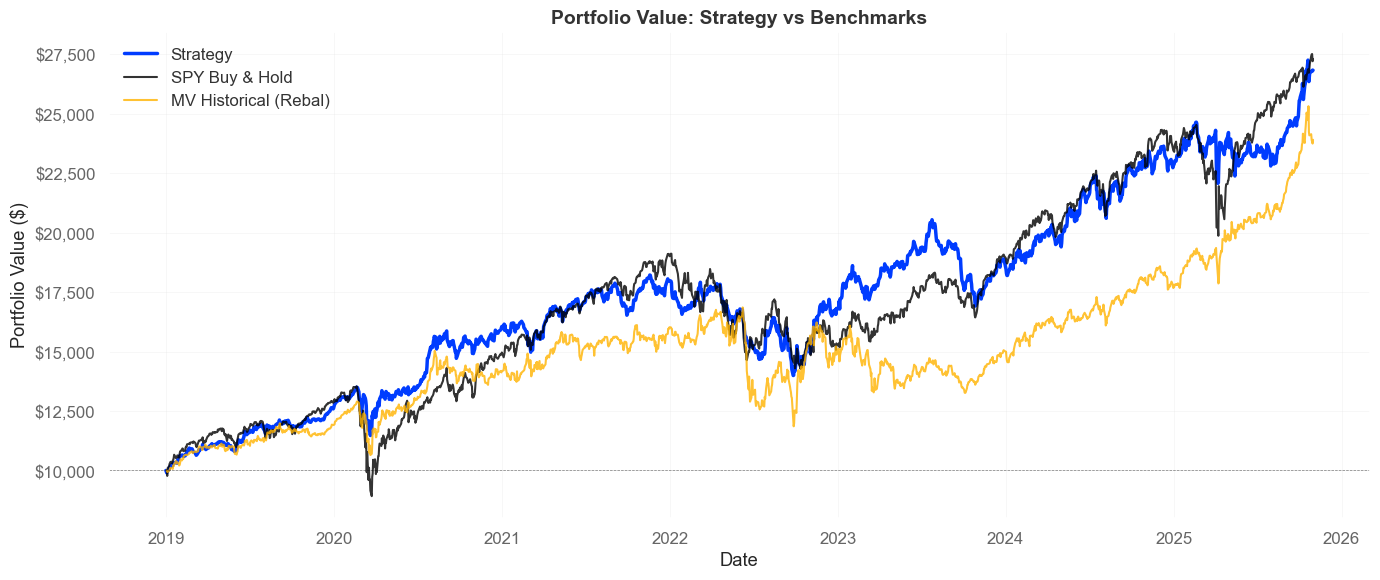

In [13]:
bt.plot_performance(start_date=EVAL_SDTE, end_date=EVAL_EDTE)

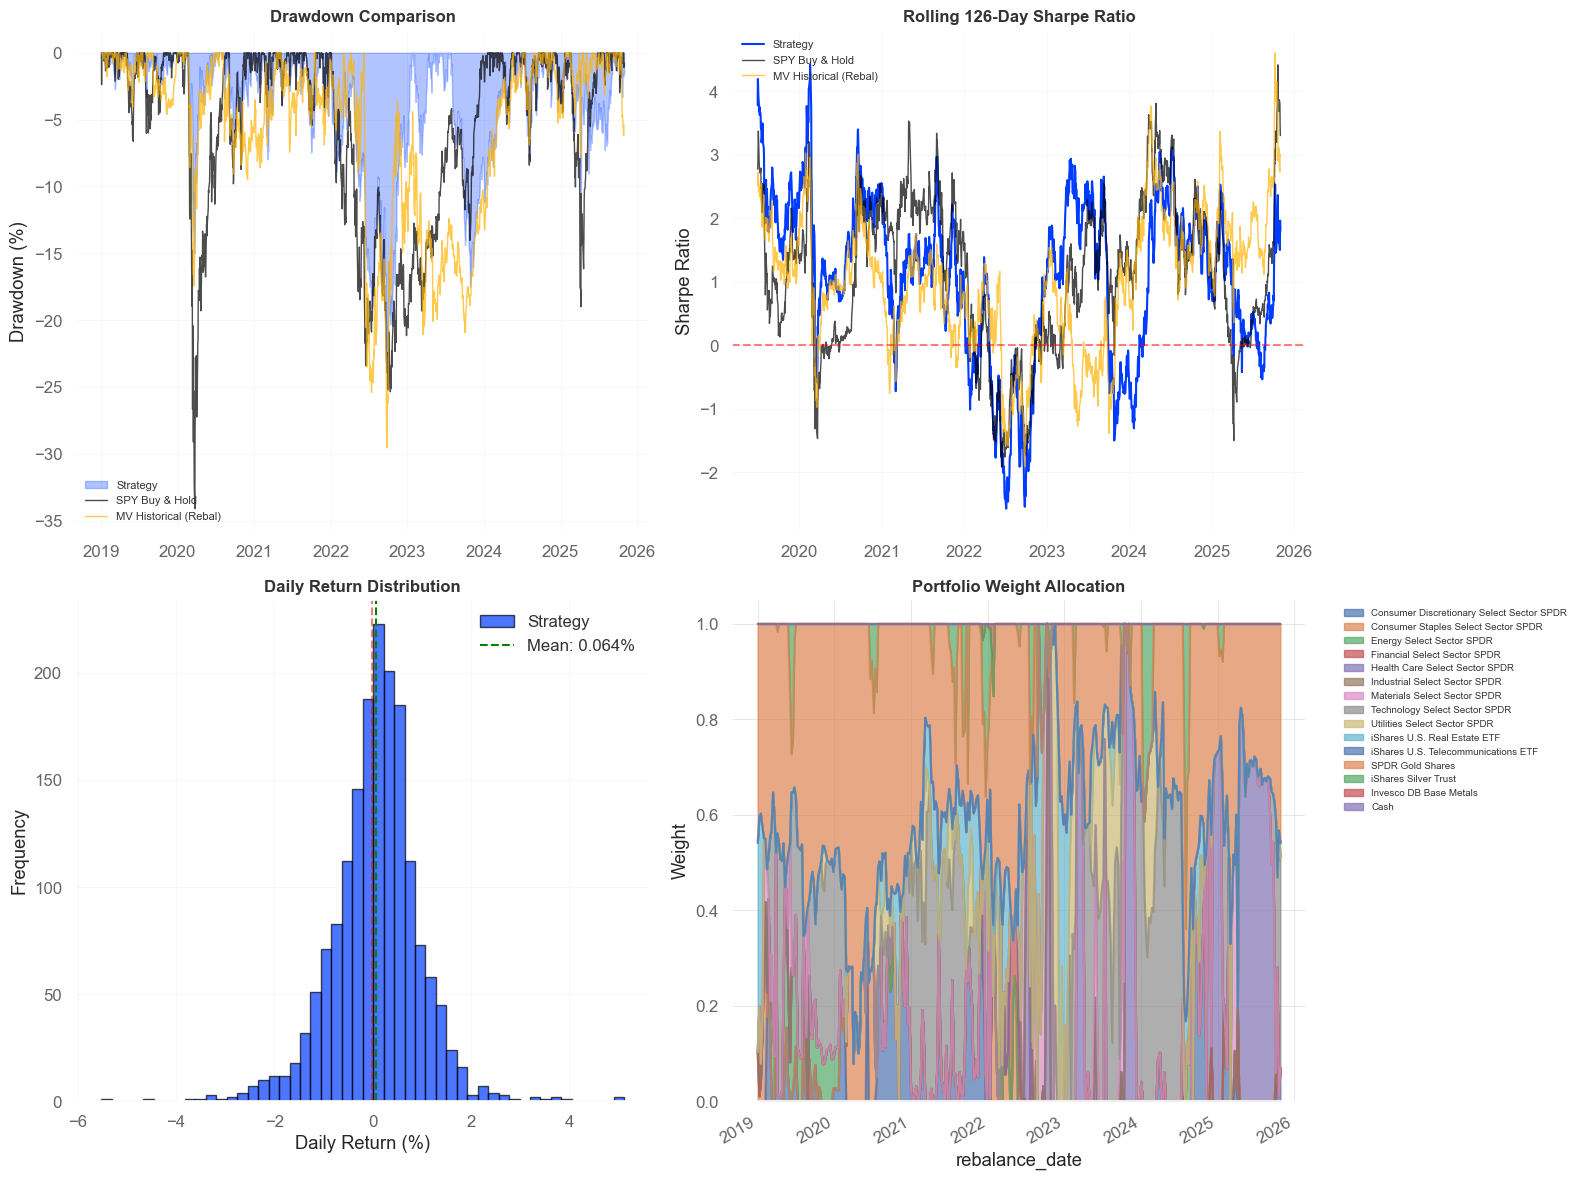

In [14]:
bt.plot_detailed_analysis(start_date=EVAL_SDTE, end_date=EVAL_EDTE)

In [15]:
bt.print_summary(start_date=EVAL_SDTE, end_date=EVAL_EDTE)


BACKTEST PERFORMANCE SUMMARY
Period: 2018-12-31 to 2025-10-31
Trading Days: 1719
Rebalances: 344

Metric                           Strategy         SPY B&H   MV Hist Rebal
-------------------------------------------------------------------------------------
Total Return                      168.23%         172.63%         138.99%
Annualized Return                  15.56%          15.84%          13.62%
Annualized Volatility              14.24%          19.99%          17.73%
Sharpe Ratio                        0.902           0.656           0.615
Sortino Ratio                       1.237           0.800           0.751
Max Drawdown                      -22.61%         -34.10%         -29.56%
Calmar Ratio                        0.688           0.464           0.461
Win Rate                           56.66%          55.61%          55.50%
Avg Daily Return                    0.06%           0.07%           0.06%
Skewness                           -0.203          -0.296          -0.612
K

In [16]:
bt.get_metrics(start_date=EVAL_SDTE, end_date=EVAL_EDTE)

,Strategy,SPY Buy & Hold,MV Historical (Rebal)
Total Return,1.682275,1.726277,1.389949
Annualized Return,0.155626,0.158386,0.136241
Annualized Volatility,0.142354,0.199860,0.177291
Sharpe Ratio,0.902019,0.656289,0.614928
Sortino Ratio,1.236984,0.799641,0.751334
Max Drawdown,-0.226074,-0.341047,-0.295586
Calmar Ratio,0.688385,0.464410,0.460920
Win Rate,0.566608,0.556137,0.554974
Avg Daily Return,0.000637,0.000664,0.000583
Skewness,-0.203039,-0.295732,-0.611783


In [17]:
bt.get_exposure_summary()

,long,short,net,gross
date,,,,
2018-12-31,1.0,-0.0,1.0,1.0
2019-01-08,1.0,-0.0,1.0,1.0
2019-01-15,1.0,-0.0,1.0,1.0
2019-01-23,1.0,-0.0,1.0,1.0
2019-01-30,1.0,-0.0,1.0,1.0
...,...,...,...,...
2025-09-29,1.0,-0.0,1.0,1.0
2025-10-06,1.0,-0.0,1.0,1.0
2025-10-13,1.0,-0.0,1.0,1.0


In [18]:
bt.weights_history.map("{:.2%}".format).loc[EVAL_SDTE:EVAL_EDTE]

,Consumer Discretionary Select Sector SPDR,Consumer Staples Select Sector SPDR,Energy Select Sector SPDR,Financial Select Sector SPDR,Health Care Select Sector SPDR,Industrial Select Sector SPDR,Materials Select Sector SPDR,Technology Select Sector SPDR,Utilities Select Sector SPDR,iShares U.S. Real Estate ETF,iShares U.S. Telecommunications ETF,SPDR Gold Shares,iShares Silver Trust,Invesco DB Base Metals,Cash
rebalance_date,,,,,,,,,,,,,,,
2018-12-31,0.00%,10.32%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,43.80%,0.00%,45.88%,0.00%,0.00%,0.00%
2019-01-08,0.00%,1.08%,0.00%,0.00%,18.87%,0.00%,0.00%,0.00%,0.00%,39.52%,0.00%,40.53%,0.00%,0.00%,0.00%
2019-01-15,0.00%,4.52%,0.00%,0.00%,0.00%,0.00%,3.37%,0.00%,0.00%,52.40%,0.00%,39.71%,0.00%,0.00%,0.00%
2019-01-23,0.00%,15.39%,0.00%,0.00%,0.00%,0.00%,2.15%,0.00%,0.00%,39.75%,0.00%,42.71%,0.00%,0.00%,0.00%
2019-01-30,0.00%,29.24%,2.77%,0.00%,0.00%,0.00%,23.02%,0.00%,0.00%,0.00%,0.00%,44.96%,0.00%,0.00%,0.00%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-29,0.00%,0.00%,0.00%,0.00%,34.31%,0.00%,0.00%,28.14%,0.00%,0.00%,0.00%,37.55%,0.00%,0.00%,0.00%
2025-10-06,0.00%,5.94%,0.00%,0.00%,0.00%,0.00%,0.00%,53.06%,0.00%,0.00%,0.00%,41.00%,0.00%,0.00%,0.00%
2025-10-13,19.37%,8.67%,0.00%,0.00%,0.00%,0.00%,0.00%,18.90%,0.00%,0.00%,0.00%,53.06%,0.00%,0.00%,0.00%


In [22]:
bt.weights_history.loc[EVAL_SDTE:EVAL_EDTE].describe()

,Consumer Discretionary Select Sector SPDR,Consumer Staples Select Sector SPDR,Energy Select Sector SPDR,Financial Select Sector SPDR,Health Care Select Sector SPDR,Industrial Select Sector SPDR,Materials Select Sector SPDR,Technology Select Sector SPDR,Utilities Select Sector SPDR,iShares U.S. Real Estate ETF,iShares U.S. Telecommunications ETF,SPDR Gold Shares,iShares Silver Trust,Invesco DB Base Metals,Cash
count,3.440000e+02,3.440000e+02,3.440000e+02,3.440000e+02,3.440000e+02,3.440000e+02,3.440000e+02,344.000000,3.440000e+02,3.440000e+02,3.440000e+02,344.000000,3.440000e+02,3.440000e+02,344.0
mean,5.178373e-02,2.412769e-02,2.118514e-02,6.448069e-03,1.058563e-01,4.903325e-03,3.735104e-02,0.209308,6.118305e-02,6.649581e-02,3.927534e-04,0.378085,3.199898e-02,8.807205e-04,0.0
std,1.050867e-01,7.106033e-02,5.633066e-02,3.999264e-02,2.550803e-01,2.851862e-02,1.282434e-01,0.229437,1.394378e-01,1.355810e-01,6.193542e-03,0.188307,8.623662e-02,9.275055e-03,0.0
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.0
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.268553,0.000000e+00,0.000000e+00,0.0
50%,1.752989e-16,8.275497e-17,0.000000e+00,0.000000e+00,2.022489e-17,0.000000e+00,0.000000e+00,0.098845,1.009283e-16,1.705634e-16,0.000000e+00,0.396933,0.000000e+00,0.000000e+00,0.0
75%,4.268702e-02,7.074602e-16,6.307140e-16,2.276019e-16,4.469210e-16,1.550067e-16,3.707854e-16,0.415802,2.268237e-13,7.439324e-02,1.426040e-16,0.499415,8.411754e-16,2.488073e-16,0.0
max,5.106506e-01,3.943685e-01,3.494889e-01,4.113830e-01,1.000000e+00,2.363576e-01,9.391794e-01,0.750382,9.566354e-01,7.507049e-01,1.139534e-01,0.920929,6.394387e-01,1.513532e-01,0.0


In [20]:
bt.get_benchmark_weights('MV Historical (Rebal)').map("{:.2%}".format).loc[EVAL_SDTE:EVAL_EDTE]

,Consumer Discretionary Select Sector SPDR,Consumer Staples Select Sector SPDR,Energy Select Sector SPDR,Financial Select Sector SPDR,Health Care Select Sector SPDR,Industrial Select Sector SPDR,Materials Select Sector SPDR,Technology Select Sector SPDR,Utilities Select Sector SPDR,iShares U.S. Real Estate ETF,iShares U.S. Telecommunications ETF,SPDR Gold Shares,iShares Silver Trust,Invesco DB Base Metals
rebalance_date,,,,,,,,,,,,,,
2018-12-31,0.00%,0.00%,0.00%,0.00%,34.37%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,65.63%,0.00%,0.00%
2019-01-08,20.94%,0.00%,0.00%,0.00%,34.85%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,44.21%,0.00%,0.00%
2019-01-15,44.84%,0.00%,0.00%,0.00%,55.16%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
2019-01-23,8.52%,0.00%,0.00%,0.00%,37.06%,0.00%,0.00%,0.00%,54.42%,0.00%,0.00%,0.00%,0.00%,0.00%
2019-01-30,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,50.54%,49.46%,0.00%,0.00%,0.00%,0.00%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-29,1.20%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,42.24%,56.56%,0.00%,0.00%
2025-10-06,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,42.39%,57.61%,0.00%,0.00%
2025-10-13,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,37.65%,60.04%,2.32%,0.00%


In [21]:
bt.get_benchmark_weights('MV Historical (Rebal)').loc[EVAL_SDTE:EVAL_EDTE].describe()

,Consumer Discretionary Select Sector SPDR,Consumer Staples Select Sector SPDR,Energy Select Sector SPDR,Financial Select Sector SPDR,Health Care Select Sector SPDR,Industrial Select Sector SPDR,Materials Select Sector SPDR,Technology Select Sector SPDR,Utilities Select Sector SPDR,iShares U.S. Real Estate ETF,iShares U.S. Telecommunications ETF,SPDR Gold Shares,iShares Silver Trust,Invesco DB Base Metals
count,3.440000e+02,3.440000e+02,3.440000e+02,3.440000e+02,3.440000e+02,3.440000e+02,3.440000e+02,3.440000e+02,3.440000e+02,3.440000e+02,3.440000e+02,3.440000e+02,3.440000e+02,3.440000e+02
mean,1.759036e-02,2.736110e-02,1.398791e-01,8.538883e-02,2.925614e-02,1.242144e-02,8.916125e-04,1.405176e-01,7.601780e-02,3.289006e-02,3.632537e-02,3.205025e-01,1.109281e-02,6.986528e-02
std,6.718684e-02,8.168289e-02,3.022494e-01,1.526950e-01,8.353657e-02,5.903064e-02,6.507891e-03,1.805940e-01,1.547321e-01,8.864132e-02,1.171216e-01,2.775731e-01,4.510475e-02,1.620387e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.739748e-16,0.000000e+00,0.000000e+00,0.000000e+00,4.194922e-16,0.000000e+00,0.000000e+00
50%,2.190701e-16,1.791100e-16,1.177589e-15,5.146832e-16,1.856631e-16,8.370753e-17,1.563028e-17,6.542968e-02,5.362517e-16,1.926291e-16,1.039811e-16,3.470347e-01,1.967144e-16,3.511370e-16
75%,1.510055e-15,1.445399e-15,5.622701e-02,1.168693e-01,1.275933e-15,6.247675e-16,5.894900e-16,2.254678e-01,8.556648e-02,2.803184e-15,8.909229e-16,5.369380e-01,2.447049e-15,1.589689e-14
max,4.610466e-01,6.574221e-01,1.000000e+00,5.154457e-01,5.515910e-01,4.545481e-01,6.833375e-02,8.777269e-01,8.012842e-01,4.960095e-01,4.996127e-01,8.916276e-01,4.069774e-01,8.603890e-01
